In [17]:
"""
绘制搜索引擎upset图
"""
import os
import re

In [61]:
trapped_peps = set()

In [139]:
"""
获取所有搜索引擎：
    - Original pFind
    - pFind
    - MSFragger
    - MaxQuant
    - Comet
    的肽段层次结果，并向pFind对齐(xxxxxx在pFind中删去固定修饰Carbamidomethyl，因为其他搜素引擎都不显示xxxxxx)
"""


"""
=================================================== pFind: pFind-Filtered.spectra ==================================================
"""
def get_pfind_res(path):
    print(path)
    peptides = set()
    
    f = open(path,"r")
    next(f,None)
    for i,line in enumerate(f):
        items = line.split("\t")
        is_decoy = (items[15]=="decoy")
        if is_decoy:
            continue
        # # 删除固定修饰
        # mods = items[10]
        # mod_s = ""
        # for mod in mods.split(";"):
        #     if "Car" in mod:
        #         continue
        #     mod_s += (mod+';')
        # peptide = items[5]+'\t'+mod_s  # seq+mod
        peptide = items[5]+'\t'+items[10]
        peptides.add(peptide)

        proteins = items[12].split("/")[:-1]
        flag = True
        for protein in proteins:
            if not protein.endswith("_ARATH"):
                flag = False
                break
        if flag:
            trapped_peps.add(peptide)
    f.close()
    return peptides

"""
============================================= MSFragger: peptide level q_value = 0.01 ==============================================
"""
def translate(sequence):
    msfragger2pfind = {
        "147": "Oxidation[M]",
        "43": "Acetyl[Protein-Nterm]",
    }
    sequence = sequence.strip("n")
    pfind_mod = ""  # 位置,mod;
    purified = []  # 构建净化序列（仅正常字母）
    i = 0
    n = len(sequence)
    while i < n:
        if sequence[i] == '[':
            # 1. 找到当前[对应的]的位置
            j = sequence.find(']', i + 1)
            if j == -1:  # 处理不完整的[]（跳过）
                i += 1
                continue
            # 2. 提取[xxx]中的内容
            bracketed_content = sequence[i+1:j]
            # 3. 计算[]的位置（核心修正逻辑）
            # 净化序列当前长度 = []插入点在净化序列中的下标（如插入开头，长度=0；插入A后，长度=1）
            insert_index = len(purified)
            if insert_index == 0:
                # 情况1：[]在开头（插入点下标0，左侧无字母）→ 位置0
                position = 0
            else:
                # 情况2：[]在中间/结尾（左侧有字母，位置=左侧最后一个字母的序号=insert_index）
                # 因为insert_index = 左侧最后一个字母的下标 + 1（例如左侧有A(0)，insert_index=1→位置1）
                position = insert_index
            # 4. 存储结果
            pfind_mod += f"{position},{msfragger2pfind[bracketed_content]};"
            # 5. 跳过当前[]，继续遍历
            i = j + 1
        elif sequence[i] == "C":  # 固定修饰
            purified.append(sequence[i])
            insert_index = len(purified)
            pfind_mod += f"{insert_index},Carbamidomethyl[C];"
            i += 1
        else:
            # 非[]内容：加入净化序列
            purified.append(sequence[i])
            i += 1
    purified_sequence = ''.join(purified)
    return purified_sequence, pfind_mod

def extract(xml_paths):
    total_result = list()
    for xml_path in xml_paths:
        print(xml_path)
        f = open(xml_path,"r")
        xml = f.read()
        # 把整块 <search_hit ...> ... </search_hit> 切出来
        hit_blocks = re.findall(r'<search_hit(.*?)>(.*?)</search_hit>', xml, flags=re.S)
        for attr, inner in hit_blocks:
            # --- 1. peptide ---
            seq = re.search(r'peptide="([^"]*)"', attr).group(1)
            res = re.search(r'<modification_info[^>]*modified_peptide="([^"]*)"', inner)
            if res is None:
                pep = seq
            else:
                pep = res.group(1)
            seq, mod = translate(pep)
            pep = seq+'\t'+mod
    
            # --- 2. 所有蛋白 ---
            proteins = []
            # 主蛋白
            proteins.append(re.search(r'protein="([^"]*)"', attr).group(1))
            # alternative 蛋白
            proteins += re.findall(r'<alternative_protein[^>]*\sprotein="([^"]*)"', inner)
            
            # --- 3. probability ---
            prob = re.search(r'<peptideprophet_result[^>]*\sprobability="([^"]*)"', inner)
            prob = prob.group(1) if prob else ''
    
            total_result.append((pep, seq, proteins, float(prob)))
        f.close()
    return total_result
    
def get_msfragger_res(msfragger_res_dir):
    print("MSFragger")
    xml_paths = [os.path.join(msfragger_res_dir,filename) for filename in os.listdir(msfragger_res_dir) if filename.endswith(".pep.xml")]
    total_result = extract(xml_paths)
    
    total_result = sorted(total_result, key=lambda item: item[3], reverse=True)
    fdrs = list()
    t = 1e-16
    d = 0
    peptides = set()
    for result in total_result:
        peptide = result[0]
        if peptide in peptides:
            fdrs.append(d/t)
            continue
        peptides.add(peptide)
        proteins = result[2]
        flag = True
        for protein in proteins:
            if not protein.startswith("rev_"):
                flag = False
                break
        if flag:
            d += 1
        else:
            t += 1
        fdrs.append(d/t)
    # 计算Q-value
    min_fdr = 100
    for i in range(len(fdrs)-1,-1,-1):
        fdrs[i] = min(fdrs[i], min_fdr)
        if fdrs[i]<=0.01:
            lim = i
            break
    print(t,d,lim)
    
    peptides = set()
    for i,result in enumerate(total_result):
        if i>lim:
            break
        peptide = result[0]
        if peptide in peptides:
            continue
        proteins = result[2]
        flag = True
        for protein in proteins:
            if not protein.startswith("rev_"):
                flag = False
                break
        if flag:
            continue
        peptides.add(peptide)

        flag = True   # target peptide
        for protein in proteins:
            if not protein.endswith("_ARATH"):
                flag = False
        if flag:
            trapped_peps.add(peptide)
            
    return peptides

"""
====================================================== MaxQuant: msms.txt ==========================================================
"""
def extract_parentheses_info(sequence):
    maxquant2pfind = {
        "Acetyl (Protein N-term)": "Acetyl[Protein-Nterm]",
        "Oxidation (M)": "Oxidation[M]",
        "Deamidated (N)": "Deamidated[N]"
    }
    pfind_mod = ""  # 位置,内容;
    purified = []  # 构建净化序列（仅正常字母）
    i = 0
    n = len(sequence)
    while i < n:
        if sequence[i] == '(':
            # 1. 找最外层对应的)：用计数法处理嵌套
            count = 1  # 初始计数为1（当前(）
            j = i + 1
            while j < n and count != 0:
                if sequence[j] == '(':
                    count += 1  # 遇到内层(，计数+1
                elif sequence[j] == ')':
                    count -= 1  # 遇到)，计数-1
                j += 1
            # 若找到完整的最外层()（count归0）
            if count == 0:
                # 2. 提取最外层(...)的内容（不含外层括号）
                # j-1是最外层)的位置，所以内容是[i+1 : j-1]
                parentheses_content = sequence[i+1 : j-1]
                # 3. 计算位置（规则同前：开头为0，否则为前一个字母的序号）
                insert_index = len(purified)
                position = 0 if insert_index == 0 else insert_index
                # 4. 存储结果
                pfind_mod += f"{position},{maxquant2pfind[parentheses_content]};"
                # 5. 跳过当前最外层()，继续遍历
                i = j
            else:
                # 若没有找到对应的)（不完整的(），则将(视为普通字符
                purified.append(sequence[i])
                i += 1
        elif sequence[i] == "C":
            purified.append(sequence[i])
            insert_index = len(purified)
            pfind_mod += f"{insert_index},Carbamidomethyl[C];"
            i += 1
        else:
            # 非(字符：加入净化序列
            purified.append(sequence[i])
            i += 1
    
    purified_sequence = ''.join(purified)
    return purified_sequence, pfind_mod
    
def get_maxquant_res(path):
    print(path)
    peptides = set()
    f = open(path, "r")
    next(f,None)
    for line in f:
        items = line.strip().split("\t")
        peptide = items[7][1:-1]
        seq, mod = extract_parentheses_info(peptide)
        peptide = seq+'\t'+mod
        proteins = items[12].split(";")
        if len(proteins)==0 or proteins[0] == "":
            continue
        peptides.add(peptide)
        
        flag = True
        for protein in proteins:
            if not protein.endswith("_ARATH"):
                flag = False
                break
        if flag:
            trapped_peps.add(peptide)
            
    f.close()
    return peptides

"""
============================================== Comet: peptide_results.txt ==========================================================
"""
def extract_bracketed_info(sequence):
    comet2pfind = {
        "15.9949": "Oxidation[M]",
        "42.0106": "Acetyl[Protein-Nterm]",
        "0.9840": "Deamidated[N]"
    }
    pfind_mod = ""  # 位置,mod;
    purified = []  # 构建净化序列（仅正常字母）
    i = 0
    n = len(sequence)
    while i < n:
        if sequence[i] == '[':
            # 1. 找到当前[对应的]的位置
            j = sequence.find(']', i + 1)
            if j == -1:  # 处理不完整的[]（跳过）
                i += 1
                continue
            # 2. 提取[xxx]中的内容
            bracketed_content = sequence[i+1:j]
            # 3. 计算[]的位置（核心修正逻辑）
            # 净化序列当前长度 = []插入点在净化序列中的下标（如插入开头，长度=0；插入A后，长度=1）
            insert_index = len(purified)
            if insert_index == 0:
                # 情况1：[]在开头（插入点下标0，左侧无字母）→ 位置0
                position = 0
            else:
                # 情况2：[]在中间/结尾（左侧有字母，位置=左侧最后一个字母的序号=insert_index）
                # 因为insert_index = 左侧最后一个字母的下标 + 1（例如左侧有A(0)，insert_index=1→位置1）
                position = insert_index
            # 4. 存储结果
            pfind_mod += f"{position},{comet2pfind[bracketed_content]};"
            # 5. 跳过当前[]，继续遍历
            i = j + 1
        elif sequence[i] == "C":  # 固定修饰
            purified.append(sequence[i])
            insert_index = len(purified)
            pfind_mod += f"{insert_index},Carbamidomethyl[C];"
            i += 1
        else:
            # 非[]内容：加入净化序列
            purified.append(sequence[i])
            i += 1
    purified_sequence = ''.join(purified)
    return purified_sequence, pfind_mod
    
def get_comet_res(path):
    print(path)
    peptides = set()
    
    f = open(path, "r")
    next(f,None)
    for line in f:
        items = line.strip().split("\t")
        q_value = float(items[2])
        if q_value > 0.01:
            break
        peptide = items[4][2:-2]
        if peptide[0]=='n':
            peptide = peptide[1:]
        seq, mod = extract_bracketed_info(peptide)
        peptide = seq+'\t'+mod
        
        proteins = items[5:]
        flag = False
        for protein in proteins:
            if not protein.startswith("DECOY_"):
                flag = True
                break
        if not flag:
            continue
        peptides.add(peptide)
        
        flag = True
        for protein in proteins:
            if not protein.endswith("_ARATH"):
                flag = False
                break
        if flag:
            trapped_peps.add(peptide)
        
    f.close()
    return peptides


# # Astral
# pfind_result_path = "D:/pFindWorkspace/Astral/new/top50-complete/result/restricted-0627/pFind-Filtered.spectra"
# msfragger_result_dir = "G:/MSFraggerWorkspace/Astral/top50-restricted/"
# maxquant_result_path = "G:/MaxQuantWorkspace/Astral/top50/combined/txt/msms.txt"
# comet_result_path = "G:/CometWorkspace/Astral/top50/peptide_results.txt"
# # Gygi
# pfind_result_path = "D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/pFind-Filtered.spectra"
# msfragger_result_dir = "G:/MSFraggerWorkspace/normal/Gygi_2015_NBT/restricted/"
# maxquant_result_path = "G:/MaxQuantWorkspace/normal/Gygi_2015_NBT/msms.txt"
# comet_result_path = "G:/CometWorkspace/Gygi_2015_NBT/peptide_results.txt"
# HLA
pfind_result_path = "D:/pFindWorkspace/HLA/C3N02671-new/result/restricted-0628/pFind-Filtered.spectra"
msfragger_result_dir = "G:/MSFraggerWorkspace/HLA/C3N02671/restricted/"
maxquant_result_path = "G:/MaxQuantWorkspace/HLA/C3N02671/msms.txt"
comet_result_path = "G:/CometWorkspace/HLA/C3N02671/peptide_results.txt"
# # humangut
# pfind_result_path = "D:/pFindWorkspace/MetaProteomics/humangut-new/result/restricted/pFind-Filtered.spectra"
# msfragger_result_dir = "G:/MSFraggerWorkspace/MetaProteomics/humangut/restricted/"
# # maxquant_result_path = "G:/MaxQuantWorkspace/Humangut/combined/txt/msms.txt"
# comet_result_path = "G:/CometWorkspace/humangut/peptide_results.txt"

pfind_res = get_pfind_res(pfind_result_path)
msfragger_res = get_msfragger_res(msfragger_result_dir)
maxquant_res = get_maxquant_res(maxquant_result_path)
comet_res = get_comet_res(comet_result_path)

D:/pFindWorkspace/HLA/C3N02671-new/result/restricted-0628/pFind-Filtered.spectra
MSFragger
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180425_QE_HFX_LC2_HLAIIp_CHC_SA_normC3N02671_10_R1.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180425_QE_HFX_LC2_HLAIIp_CHC_SA_normC3N02671_10_R2.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180425_QE_HFX_LC2_HLAIIp_CHC_SA_normC3N02671_10_R3.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180425_QE_HFX_LC2_HLAIp_CHC_SA_normC3N02671_10_R1.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180425_QE_HFX_LC2_HLAIp_CHC_SA_normC3N02671_10_R2.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180425_QE_HFX_LC2_HLAIp_CHC_SA_normC3N02671_10_R3.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180426_QE_HFX_LC2_HLAIIp_CHC_SA_tumC3N02671_08_R1.pep.xml
G:/MSFraggerWorkspace/HLA/C3N02671/restricted/interact-20180426_QE_HFX_LC2_HLAIIp_CHC_SA_tumC3N02671_

In [238]:
"""
求交集：
    求目标搜索引擎与其余各搜索引擎的交集
"""
import pandas as pd
import itertools

target = pfind_res
others = [msfragger_res, maxquant_res, comet_res]
index_names = ['pFind', 'MSFragger', 'MaxQuant', 'Comet']
# 获取其他搜索引擎的数量
n_others = len(others)
if n_others == 0:
    raise ValueError("至少需要一个其他搜索引擎的结果")

# 生成其他搜索引擎的所有可能组合（2^n种）
# 每种组合用布尔值表示：True表示包含该搜索引擎，False表示不包含
other_combinations = list(itertools.product([False, True], repeat=n_others))

# 准备结果数据
data = {}

# 目标搜索引擎必须为True，遍历其他搜索引擎的所有组合
for combo in other_combinations:
    # 必须包含目标搜索引擎
    current_set = target.copy()
    
    # 处理组合中为True的搜索引擎（取交集）
    for i, include in enumerate(combo):
        if include:
            current_set &= others[i]
    
    # 处理组合中为False的搜索引擎（排除这些搜索引擎中的肽段）
    excluded = set()
    for i, include in enumerate(combo):
        if not include:
            excluded.update(others[i])
    current_set -= excluded
    
    # 记录当前组合的计数
    # 索引构建：(目标是否包含, 其他1是否包含, 其他2是否包含, ...)
    index_tuple = (True,) + combo
    data[index_tuple] = len(current_set)

# 转换为pandas Series并设置索引名称
series = pd.Series(data, name='value')

# 设置索引名称（目标搜索引擎为'target'，其他为'other_0', 'other_1', ...）

series.index.names = index_names

print(series)

pFind  MSFragger  MaxQuant  Comet
True   False      False     False    41617
                            True         0
                  True      False        8
                            True         0
       True       False     False    64990
                            True         0
                  True      False       11
                            True         0
Name: value, dtype: int64


In [64]:
"""
求交集：
    求各搜索引擎的交集(peptide)
"""
import pandas as pd
import itertools

# target = pfind_res
# others = [msfragger_res, maxquant_res, comet_res]
totals = [pfind_res, msfragger_res, maxquant_res, comet_res]
index_names = ['pFind', 'MSFragger', 'MaxQuant', 'Comet']
# 获取其他搜索引擎的数量
n_total = len(totals)

# 生成其他搜索引擎的所有可能组合（2^n种）
# 每种组合用布尔值表示：True表示包含该搜索引擎，False表示不包含
combinations = list(itertools.product([False, True], repeat=n_total))
total_set = set()
for i in totals:
    total_set |= i

# 准备结果数据
data = {}
# 目标搜索引擎必须为True，遍历其他搜索引擎的所有组合
for combo in combinations:
    if not any(combo):
        continue
    # 必须包含目标搜索引擎
    current_set = total_set.copy()
    
    # 处理组合中为True的搜索引擎（取交集）
    for i, include in enumerate(combo):
        if include:
            current_set &= totals[i]
    
    # 处理组合中为False的搜索引擎（排除这些搜索引擎中的肽段）
    excluded = set()
    for i, include in enumerate(combo):
        if not include:
            excluded.update(totals[i])
    current_set -= excluded
    
    # 记录当前组合的计数
    # 索引构建：(目标是否包含, 其他1是否包含, 其他2是否包含, ...)
    index_tuple = combo
    data[index_tuple] = len(current_set)

    if combo == (False,False,False,True):
        a = current_set

# 转换为pandas Series并设置索引名称
series = pd.Series(data, name='value')

# 设置索引名称（目标搜索引擎为'target'，其他为'other_0', 'other_1', ...）

series.index.names = index_names

print(series)

pFind  MSFragger  MaxQuant  Comet
False  False      False     True       1614
                  True      False      2470
                            True        550
       True       False     False      2986
                            True        691
                  True      False      1633
                            True        903
True   False      False     False     29267
                            True       1346
                  True      False      4786
                            True       1430
       True       False     False      6094
                            True      10899
                  True      False      5237
                            True     116442
Name: value, dtype: int64


G:\downloads\anaconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
G:\downloads\anaconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

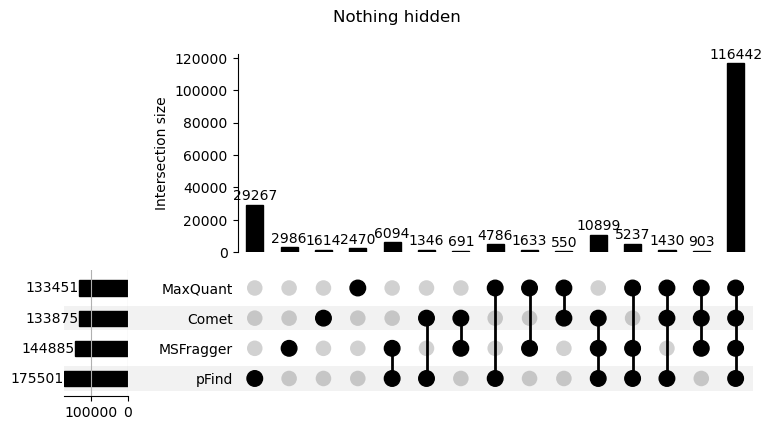

In [65]:
from matplotlib import pyplot as plt
from upsetplot import generate_counts, plot, UpSet

plot(series, show_counts=True)
plt.grid(False)
plt.suptitle('Nothing hidden')
plt.show()

MaxQuant 2470 172
Comet 1614 494
MSFragger 2986 422
pFind-new 29267 615


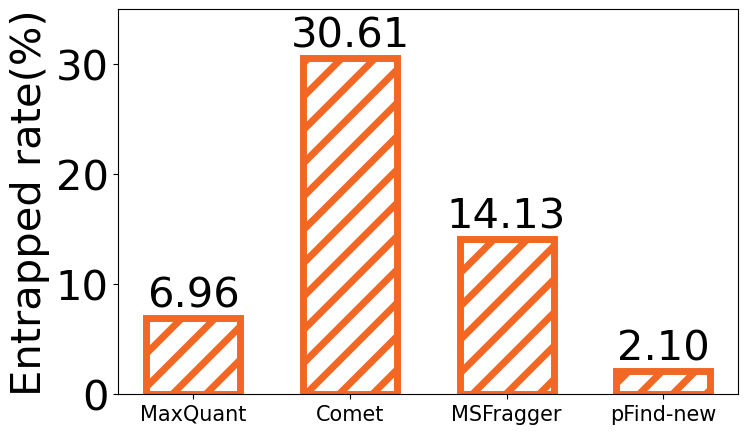

In [137]:
import matplotlib.pyplot as plt

total_res = [maxquant_res, comet_res, msfragger_res, pfind_res]
labels = ["MaxQuant", "Comet", "MSFragger", "pFind-new"]
fig, ax = plt.subplots(figsize=(8,5))
plt.rcParams['hatch.linewidth'] = 5

for i in range(len(total_res)):
    cur_res = total_res[i].copy()
    for j in range(len(total_res)):
        if j==i:
            continue
        cur_res -= total_res[j]
    trapped_num = 0
    for pep in cur_res:
        if pep in trapped_peps:
            trapped_num += 1
    print(labels[i], len(cur_res), trapped_num)
    ratio = trapped_num / len(cur_res)
    ax.bar(i+1, ratio*100, width=0.6, color='white', edgecolor="#F26723", hatch='/', linewidth=5)
    ax.text(i+1, ratio*100 + 0.2, f'{ratio*100:.2f}', ha='center', va='bottom', fontsize=30)

# 坐标轴
ax.set_ylabel('Entrapped rate(%)', fontsize=30)              # 隐藏 x 刻度
ax.set_ylim(0, 35)
ax.tick_params(axis='y', labelsize=30)  # y轴刻度值字体大小
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(labels, fontsize=15)
plt.show()

In [141]:
"""
求交集：
    求各搜索引擎的交集(seq)
"""
import pandas as pd
import itertools

pfind_seq = set()
for pep in pfind_res:
    seq,mod = pep.split("\t")
    pfind_seq.add(seq)
msfragger_seq = set()
for pep in msfragger_res:
    seq,mod = pep.split("\t")
    msfragger_seq.add(seq)
maxquant_seq = set()
for pep in maxquant_res:
    seq,mod = pep.split("\t")
    maxquant_seq.add(seq)
comet_seq = set()
for pep in comet_res:
    seq,mod = pep.split("\t")
    comet_seq.add(seq)
    
totals = [pfind_seq, msfragger_seq, maxquant_seq, comet_seq]
index_names = ['pFind', 'MSFragger', 'MaxQuant', 'Comet']
# 获取其他搜索引擎的数量
n_total = len(totals)

# 生成其他搜索引擎的所有可能组合（2^n种）
# 每种组合用布尔值表示：True表示包含该搜索引擎，False表示不包含
combinations = list(itertools.product([False, True], repeat=n_total))
total_set = set()
for i in totals:
    total_set |= i

# 准备结果数据
data = {}
# 目标搜索引擎必须为True，遍历其他搜索引擎的所有组合
for combo in combinations:
    if not any(combo):
        continue
    # 必须包含目标搜索引擎
    current_set = total_set.copy()
    
    # 处理组合中为True的搜索引擎（取交集）
    for i, include in enumerate(combo):
        if include:
            current_set &= totals[i]
    
    # 处理组合中为False的搜索引擎（排除这些搜索引擎中的肽段）
    excluded = set()
    for i, include in enumerate(combo):
        if not include:
            excluded.update(totals[i])
    current_set -= excluded
    
    # 记录当前组合的计数
    # 索引构建：(目标是否包含, 其他1是否包含, 其他2是否包含, ...)
    index_tuple = combo
    data[index_tuple] = len(current_set)

    if combo == (False,False,False,True):
        a = current_set

# 转换为pandas Series并设置索引名称
series = pd.Series(data, name='value')

# 设置索引名称（目标搜索引擎为'target'，其他为'other_0', 'other_1', ...）

series.index.names = index_names

print(series)

pFind  MSFragger  MaxQuant  Comet
False  False      False     True      481
                  True      False     275
                            True       32
       True       False     False    1244
                            True      461
                  True      False      85
                            True      178
True   False      False     False    2971
                            True      540
                  True      False     150
                            True      101
       True       False     False    2809
                            True     5204
                  True      False     528
                            True     6691
Name: value, dtype: int64


G:\downloads\anaconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
G:\downloads\anaconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

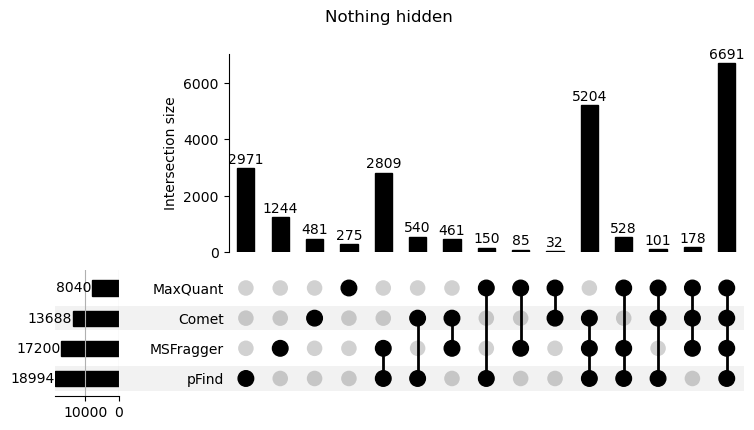

In [145]:
from matplotlib import pyplot as plt
from upsetplot import generate_counts, plot, UpSet

plot(series, show_counts=True)
plt.grid(False)
plt.suptitle('Nothing hidden')
plt.show()

In [143]:
"""
得到每个搜索引擎单独鉴定到的Sequence，制作{Engine}_peptide.txt，用于NetMHCPan预测
"""
import matplotlib.pyplot as plt

total_res = [maxquant_seq, comet_seq, msfragger_seq, pfind_seq]
labels = ["MaxQuant", "Comet", "MSFragger", "pFind-new"]

for i in range(len(total_res)):
    filename = f"{labels[i]}_peptide.txt"
    f = open(filename,"w")
    cur_res = total_res[i].copy()
    for j in range(len(total_res)):
        if j==i:
            continue
        cur_res -= total_res[j]
    for j,seq in enumerate(cur_res):
        f.write(f">peptide_{j}\n")
        f.write(seq+"\n")
    f.close()

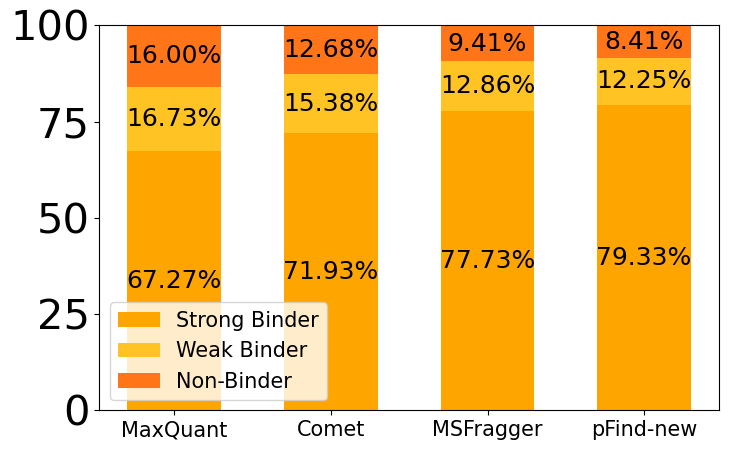

In [199]:
import matplotlib.pyplot as plt

total_res = [maxquant_seq, comet_seq, msfragger_seq, pfind_seq]
engines = ["MaxQuant", "Comet", "MSFragger", "pFind-new"]
labels = ["Strong Binder", "Weak Binder", "Non-Binder"]
colors = ["#FFA500","#FFC323","#FF7518"]
# (sb,wb,nb)
bindings = [
    [185,46,44],
    [346,74,61],
    [967,160,117],
    [2357,364,250],
]
fig, ax = plt.subplots(figsize=(8,5))
plt.rcParams['hatch.linewidth'] = 5

for i in range(len(total_res)):
    cur_res = total_res[i].copy()
    for j in range(len(total_res)):
        if j==i:
            continue
        cur_res -= total_res[j]
    summ = 0
    for j in range(3):
        ax.bar(i+1, bindings[i][j]/len(cur_res)*100, width=0.6, bottom=summ/len(cur_res)*100,
               color=colors[j], label=labels[j] if i==0 else None)
        ax.text(i+1, (summ+bindings[i][j]/2)/len(cur_res)*100, f'{bindings[i][j]/len(cur_res)*100:.2f}%', 
                ha='center', va='center', fontsize=18)
        summ += bindings[i][j]

# 坐标轴
# ax.set_ylabel('Entrapped rate(%)', fontsize=30)              # 隐藏 x 刻度
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=30)  # y轴刻度值字体大小
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(engines, fontsize=15)
ax.legend(fontsize=15)
plt.show()